In [785]:
# Data handling
import pandas as pd
import numpy as np
import os
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Date and time operations
from datetime import datetime

# Preprocessing & Scaling
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Dimensionality reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Machine Learning
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Streamlit (Deployment)
import streamlit as st

# Warnings
import warnings
warnings.filterwarnings("ignore")

In [787]:
import os

os.getcwd()

'C:\\Users\\soham\\Desktop\\customer_analytics_project\\notebooks'

In [789]:
import pandas as pd

excel_file = pd.ExcelFile(r"C:\Users\soham\Desktop\customer_analytics_project\data\raw\Online Retail.xlsx")
print(excel_file.sheet_names)

['Online Retail']


In [791]:
df = pd.read_excel(r"C:\Users\soham\Desktop\customer_analytics_project\data\raw\Online Retail.xlsx")

In [793]:
df.shape

(541909, 8)

In [795]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [797]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [799]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [801]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [803]:
(df.isnull().sum() * 100)/df.shape[0]

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [805]:
df.duplicated().sum()

5268

In [806]:
negative_qty = (df['Quantity'] < 0).sum()
print("\nNegative Quantity rows:", negative_qty)

negative_qty = (df['UnitPrice'] < 0).sum()
print("\nNegative UnitPrice rows:", negative_qty)


Negative Quantity rows: 10624

Negative UnitPrice rows: 2


In [807]:
cancelled_invoices = df['InvoiceNo'].astype(str).str.startswith('C').sum()
print("Cancelled invoices:", cancelled_invoices)

Cancelled invoices: 9288


In [810]:
print("\n===== Top Countries =====")
print(df['Country'].value_counts().head())


===== Top Countries =====
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64


In [811]:
print("\n===== Numerical Columns Summary =====")
display(df.describe())


===== Numerical Columns Summary =====


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [813]:
df.Country.unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [816]:
# Negative quantity and unit prices are removed
df_rev = df[(df['Quantity']>0) | (df['UnitPrice']>0)]
df_rev

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [818]:
# Sum of Cancelled order
df['InvoiceNo'].astype(str).str.startswith('C').sum()

9288

In [820]:
df_rev = df_rev[
    ~df_rev['InvoiceNo'].astype(str).str.startswith('C')
]

In [822]:
df_rev.shape

(531285, 8)

CustomerID is the key identifier for each customer. Imputing it would create artificial or incorrect customers, which would corrupt segmentation, RFM analysis, and recommendations. Therefore, we drop all rows with missing CustomerID to ensure data integrity and accurate analysis.

In [824]:
df_rev = df_rev.dropna(subset=['CustomerID'])

In [828]:
df_rev.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [830]:
print("Duplicate rows:", df_rev.duplicated().sum())
df_rev = df_rev.drop_duplicates()

Duplicate rows: 5192


In [831]:
df_rev.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [832]:
df_rev.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [834]:
df_rev['CustomerID'] = df_rev['CustomerID'].astype('int')

## Exploratory Data Analysis (EDA)

In [839]:
df_rev['TotalAmount'] = df_rev['Quantity'] * df_rev['UnitPrice']

In [841]:
df_rev.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


Text(0.5, 1.0, 'Top 10 Countries by Revenue')

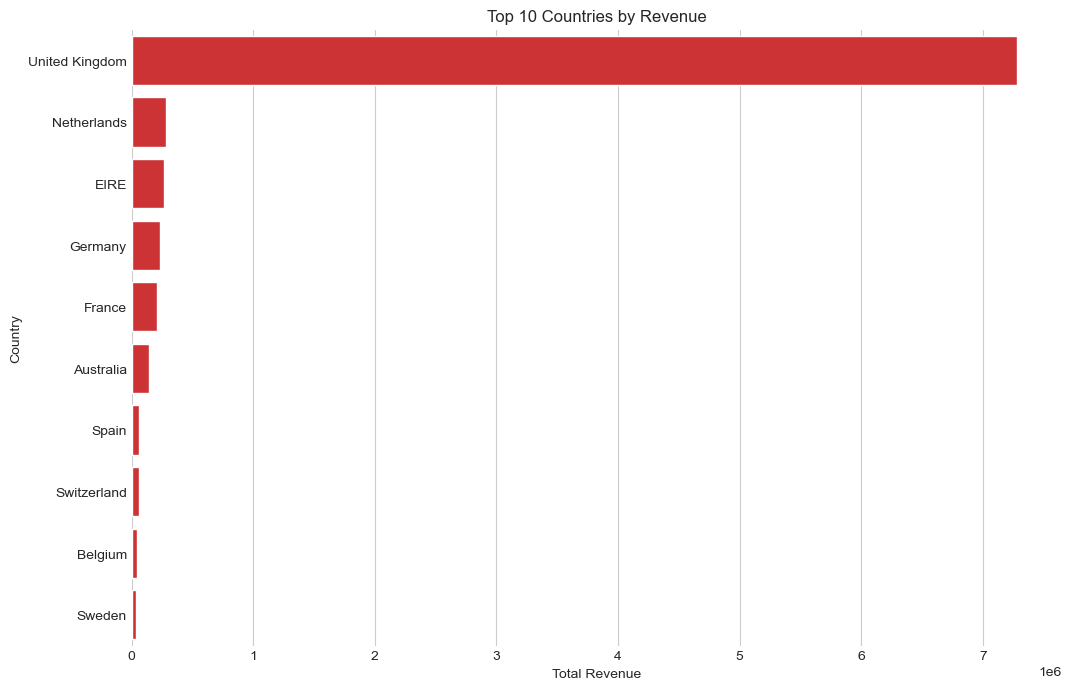

In [843]:
country_revenue = df_rev.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).reset_index()

# Plot
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=country_revenue.head(10), x='TotalAmount', y='Country')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.title('Top 10 Countries by Revenue')

### Insights:

1. The United Kingdom contributes the highest revenue by a very large margin.
2. Revenue from the UK is significantly higher than all other countries combined.
3. Netherlands, Germany, France, and Australia are the next major markets.
4. The business is highly dependent on the UK market, indicating geographical concentration risk.

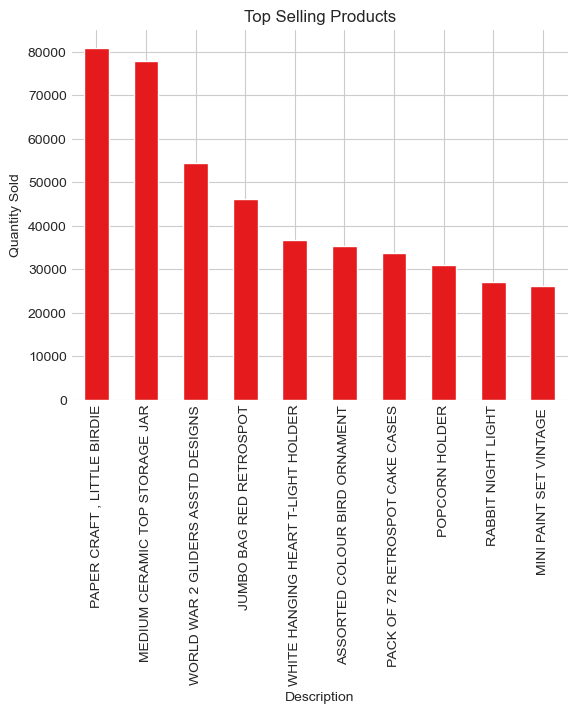

In [845]:
top_products = (
    df_rev.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products.plot(kind='bar')

plt.title("Top Selling Products")
plt.ylabel("Quantity Sold")
plt.show()

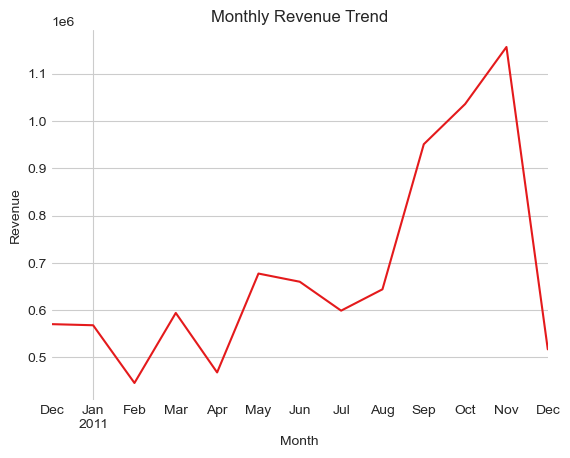

In [847]:
df_rev['Month'] = df_rev['InvoiceDate'].dt.to_period('M')
monthly_sales = (
    df_rev.groupby('Month')['TotalAmount']
    .sum()
)
monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

### Insights:

1. Revenue generally increases throughout the year.
2. Sales rise sharply from September onwards.
3. November records the highest revenue.

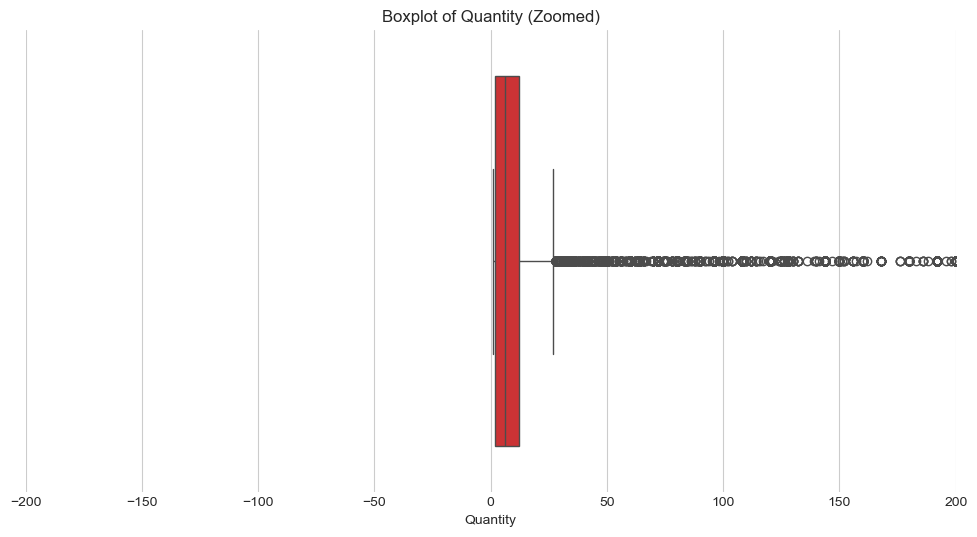

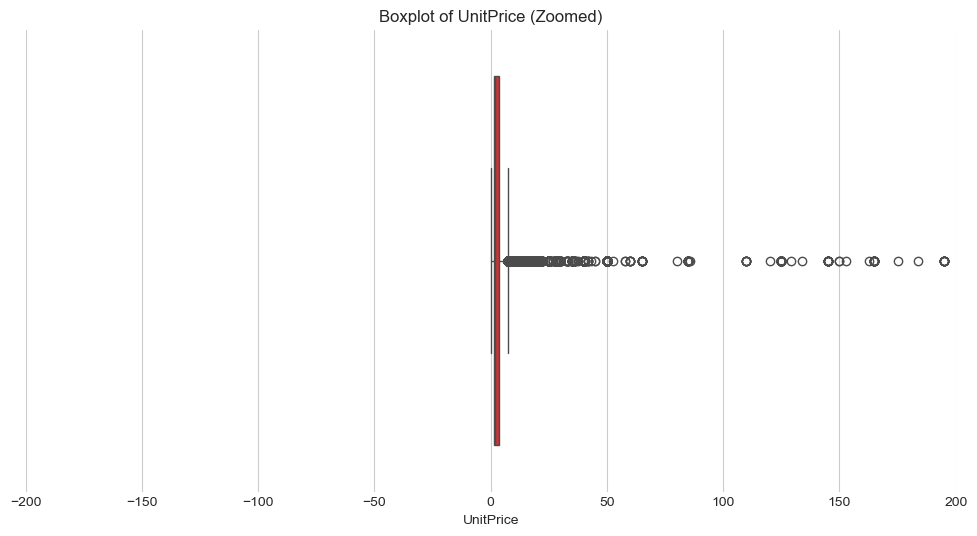

In [850]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_rev['Quantity'])
plt.title('Boxplot of Quantity (Zoomed)')
plt.xlim(-200, 200)  # Focus on reasonable range
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df_rev['UnitPrice'])
plt.title('Boxplot of UnitPrice (Zoomed)')
plt.xlim(-200, 200)  # Focus on reasonable range
plt.show()

### Insights:

1. Quantity contains several outliers.
2. Most purchases are concentrated within a small range.

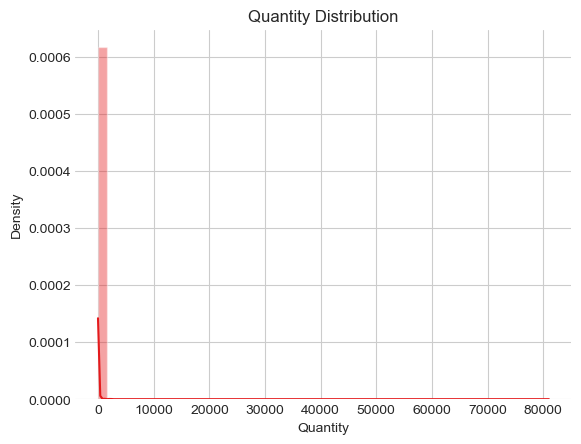

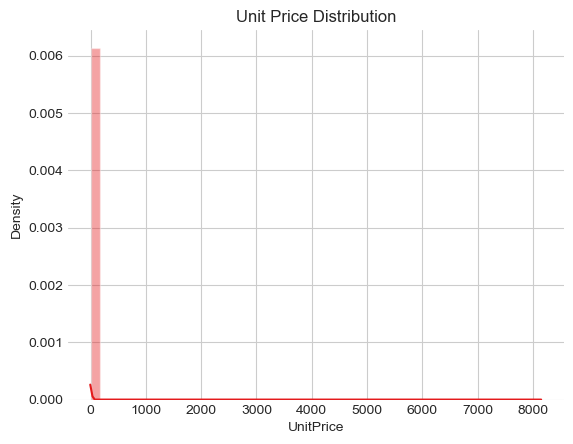

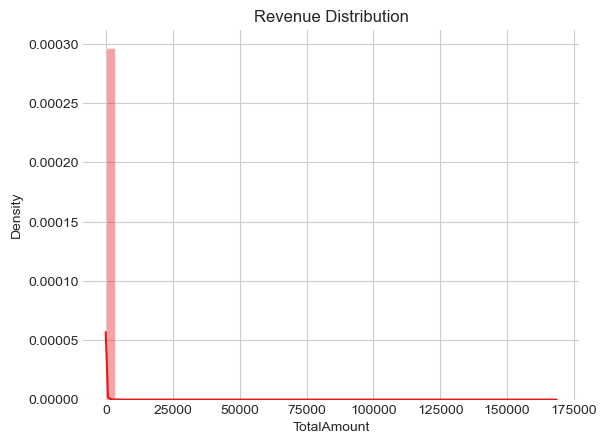

In [853]:
sns.distplot(df_rev['Quantity'], bins = 50)
plt.title("Quantity Distribution")
plt.show()

sns.distplot(df_rev['UnitPrice'], bins=50)
plt.title("Unit Price Distribution")
plt.show()

sns.distplot(df_rev['TotalAmount'], bins=50)
plt.title("Revenue Distribution")
plt.show()

### Insights:

1. Most products have relatively low prices.
2. A few products have exceptionally high prices.
3. The distribution of unit price ,quantity, total amount is positively skewed.

In [856]:
top_customers = (
    df_rev.groupby('CustomerID')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

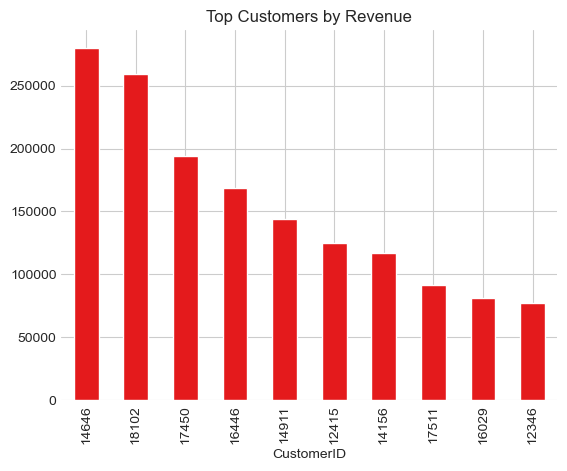

In [857]:
top_customers.plot(kind='bar')

plt.title("Top Customers by Revenue")
plt.show()

In [861]:
top_products = (
    df_rev.groupby('Description')
    .agg({
        'Quantity': 'sum',
        'UnitPrice': 'first',
        'TotalAmount': 'sum' 
    })
    .sort_values('Quantity', ascending=False)
    .head(10)
    .reset_index()
)

top_products

,Description,Quantity,UnitPrice,TotalAmount
0,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60
1,MEDIUM CERAMIC TOP STORAGE JAR,77916,1.04,81416.73
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319,0.29,13558.41
3,JUMBO BAG RED RETROSPOT,46078,1.65,85040.54
4,WHITE HANGING HEART T-LIGHT HOLDER,36706,2.55,100392.10
5,ASSORTED COLOUR BIRD ORNAMENT,35263,1.69,56413.03
6,PACK OF 72 RETROSPOT CAKE CASES,33670,0.42,16381.88
7,POPCORN HOLDER,30919,0.85,23417.51
8,RABBIT NIGHT LIGHT,27153,2.08,51251.24
9,MINI PAINT SET VINTAGE,26076,0.65,16039.24


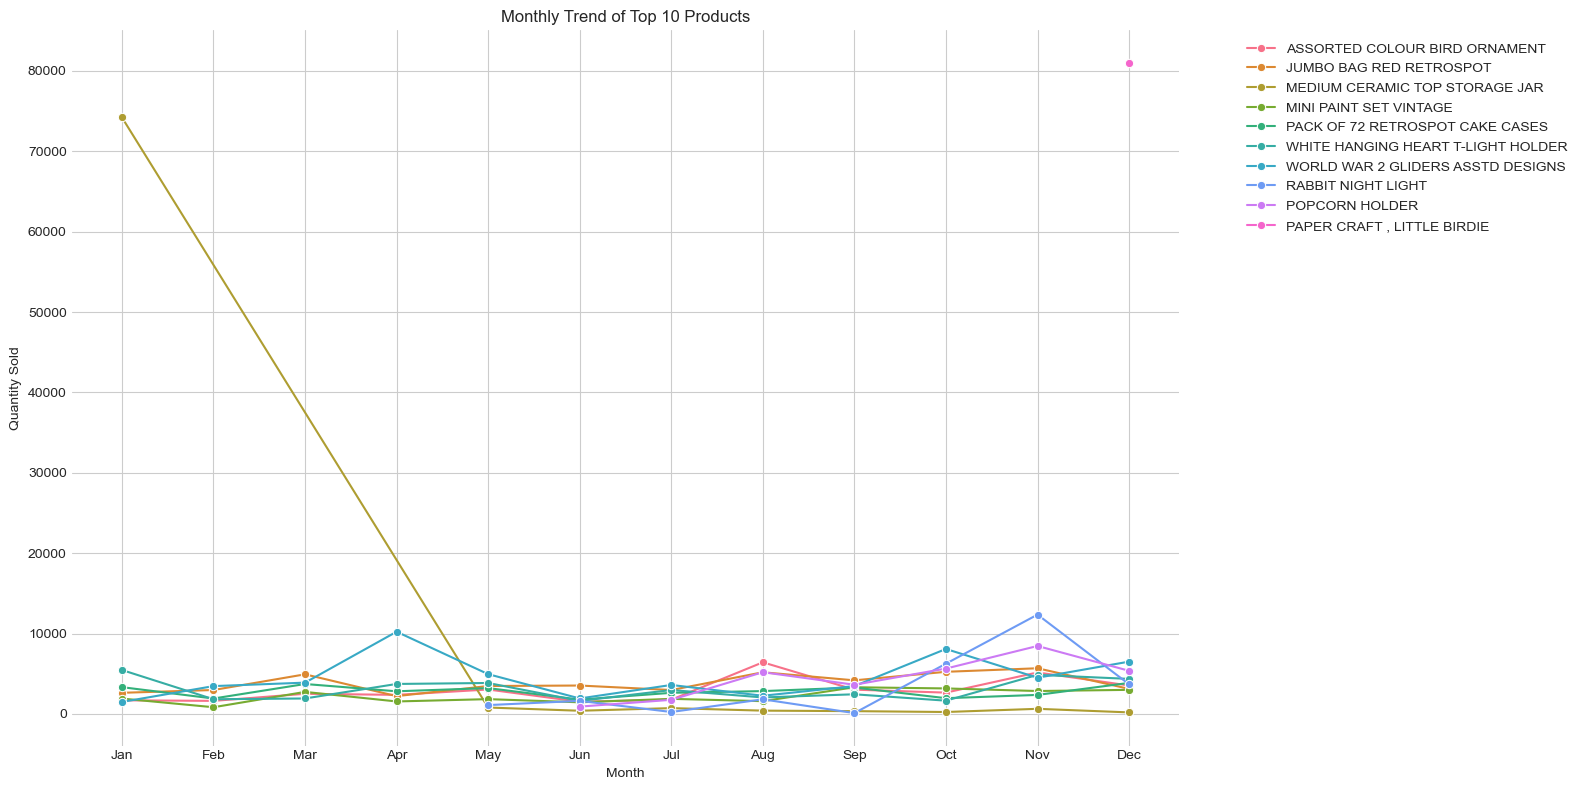

In [863]:
# Convert Month to numeric
df_rev['Month_Num'] = df_rev['Month'].astype(str).str.split('-').str[1].astype(int)

# Or simpler:
# df_rev['Month_Num'] = pd.to_datetime(df_rev['Month']).dt.month

# Now run your analysis
top_10_products = (
    df_rev.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

top_df = df_rev[df_rev['Description'].isin(top_10_products)]

monthly_sales = (
    top_df.groupby(['Month_Num', 'Description'])['Quantity']
    .sum()
    .reset_index()
)

plt.figure(figsize=(16,8))
sns.lineplot(
    data=monthly_sales,
    x='Month_Num',
    y='Quantity',
    hue='Description',
    marker='o'
)

plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title("Monthly Trend of Top 10 Products")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Insights:

1. Most top-selling products show increased demand during October and November, indicating seasonal buying patterns.

2. Several products maintain consistent sales throughout the year, suggesting stable customer demand.

3. "MEDIUM CERAMIC TOP STORAGE JAR" exhibits an unusually large sales spike in January, likely due to bulk purchases or promotional activity.

4. Some products experience demand peaks during specific months, which can help optimize inventory planning and marketing strategies.

5. Product-level monthly trends reveal that customer purchasing behavior changes over time and can be useful for demand forecasting.

### RFM Analysis

In [867]:
df_rev.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,Month_Num
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,12


In [869]:
reference_date = df_rev['InvoiceDate'].max() + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


In [871]:
rfm = df_rev.groupby('CustomerID').agg({
    
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    
    'InvoiceNo': 'nunique',
    
    'TotalAmount': 'sum'
    
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [872]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
...,...,...,...
18280,278,1,180.60
18281,181,1,80.82
18282,8,2,178.05


In [875]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2048.215924
std,100.009747,7.705493,8984.248352
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,306.455000
50%,51.000000,2.000000,668.560000
75%,142.000000,5.000000,1660.315000
max,374.000000,210.000000,280206.020000


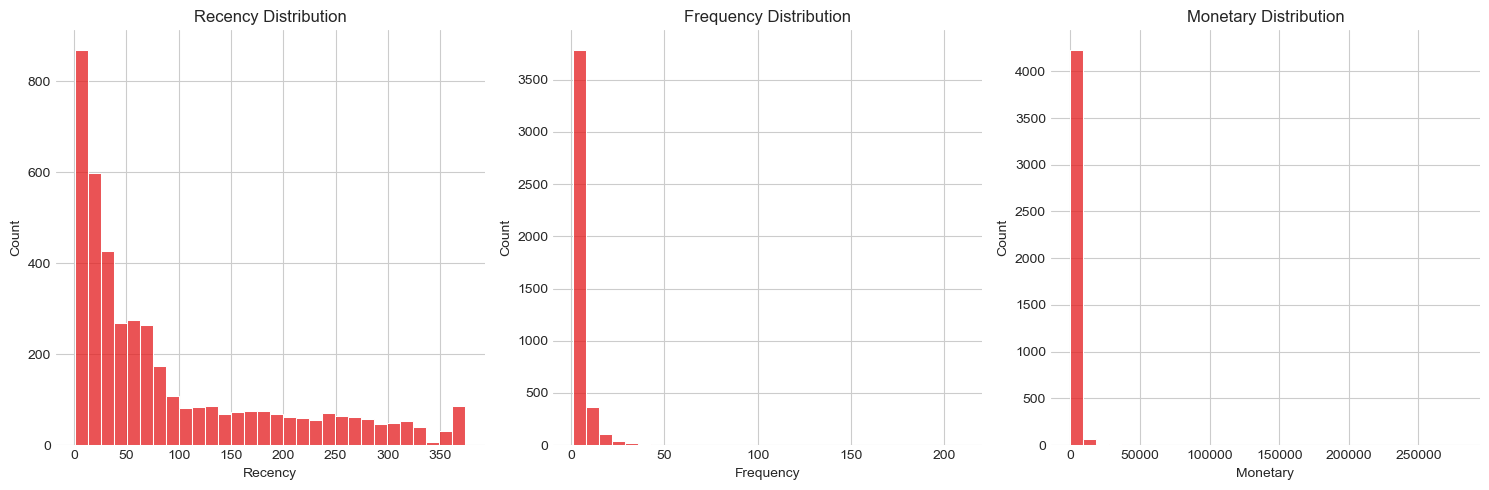

In [877]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency plot
sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Recency")

# Frequency plot
sns.histplot(rfm['Frequency'], bins=30, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Frequency")

# Monetary plot
sns.histplot(rfm['Monetary'], bins=30, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Monetary")

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

In [879]:
rfm1 = rfm.copy()

In [881]:
rfm1.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


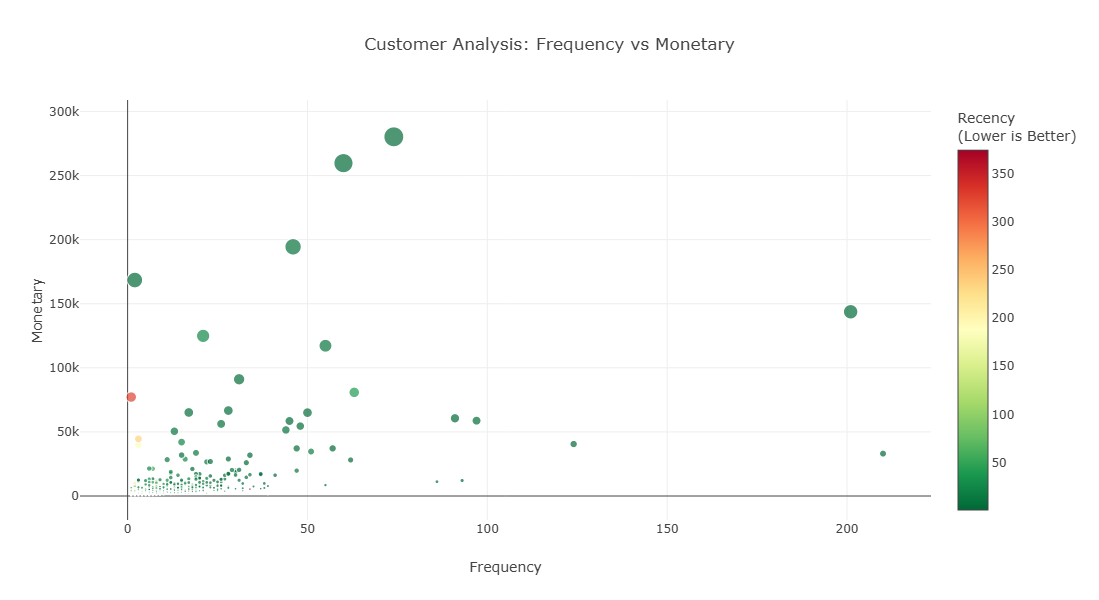

In [883]:
import plotly.express as px
import plotly.graph_objects as go

rfm1['Customer_ID'] = rfm1.index  

fig = px.scatter(
    rfm1,
    x='Frequency',
    y='Monetary',
    color='Recency',
    color_continuous_scale='RdYlGn_r',
    size='Monetary', 
    size_max=20,
    hover_data={
        'Customer_ID': True,  
        'Recency': ':.0f',  
        'Frequency': ':.0f',
        'Monetary': ':.2f'  
    },
    title='Customer Analysis: Frequency vs Monetary'
)

fig.update_layout(
    xaxis_title='Frequency',
    yaxis_title='Monetary',
    coloraxis_colorbar=dict(title='Recency<br>(Lower is Better)'),
    width=800,
    height=600
)

fig.show()

### Insights:

1. A small group of customers contributes the highest revenue (VIP customers).
2. Customers with high frequency and high monetary value are extremely valuable for the business.
3. Most customers are low-frequency, low-spending customers, forming the long tail of the distribution.
4. Recency plays an important role in identifying active vs inactive customers.
5. Business should focus on retaining high-frequency, high-monetary customers.

## DBSCAN clustering

In [887]:
rfm[['Recency','Frequency','Monetary']].skew()

Recency       1.246357
Frequency    12.100028
Monetary     19.341403
dtype: float64

In [889]:
rfm_log = rfm.copy()

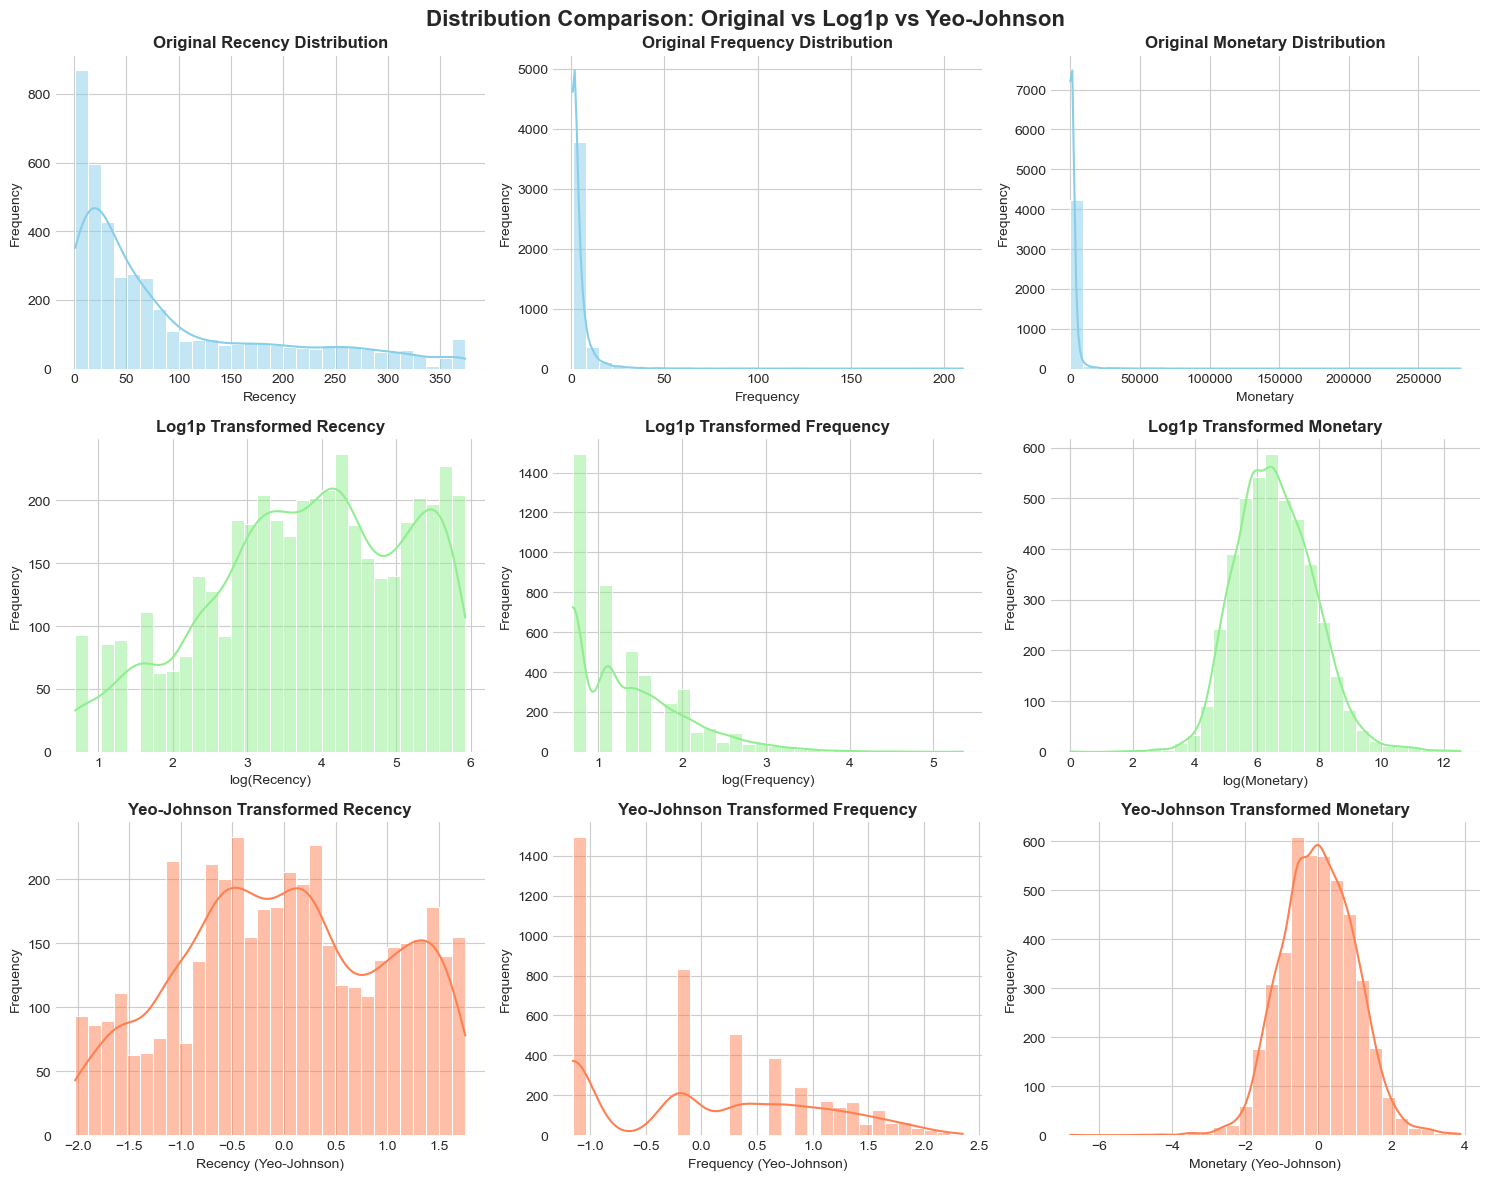


SKEWNESS COMPARISON (Lower is better - closer to 0)
Variable     Original     Log1p        Yeo-Johnson  Best        
----------------------------------------------------------------------
Recency      1.246        -0.379       -0.056       Yeo-Johnson 
Frequency    12.100       1.209        0.217        Yeo-Johnson 
Monetary     19.341       0.364        -0.023       Yeo-Johnson 


In [891]:
from sklearn.preprocessing import PowerTransformer

# Assuming you already have rfm dataframe with 'Recency', 'Frequency', 'Monetary'

# STEP 1: Apply Log1p Transformation
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency'] = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm['Monetary'])

# STEP 2: Apply Yeo-Johnson Transformation
pt = PowerTransformer(method='yeo-johnson')
rfm_yeojohnson = pt.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# STEP 3: Create figure with 3 rows and 3 columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Row 1: Original distributions
original_columns = ['Recency', 'Frequency', 'Monetary']
for i, col in enumerate(original_columns):
    sns.histplot(rfm[col], bins=30, kde=True, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'Original {col} Distribution', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel(col, fontsize=10)
    axes[0, i].set_ylabel('Frequency', fontsize=10)

# Row 2: Log1p transformed distributions
for i, col in enumerate(original_columns):
    sns.histplot(rfm_log[col], bins=30, kde=True, ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(f'Log1p Transformed {col}', fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel(f'log({col})', fontsize=10)
    axes[1, i].set_ylabel('Frequency', fontsize=10)

# Row 3: Yeo-Johnson transformed distributions
for i, col in enumerate(original_columns):
    sns.histplot(rfm_yeojohnson[:, i], bins=30, kde=True, ax=axes[2, i], color='coral')
    axes[2, i].set_title(f'Yeo-Johnson Transformed {col}', fontsize=12, fontweight='bold')
    axes[2, i].set_xlabel(f'{col} (Yeo-Johnson)', fontsize=10)
    axes[2, i].set_ylabel('Frequency', fontsize=10)

plt.suptitle('Distribution Comparison: Original vs Log1p vs Yeo-Johnson', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print skewness comparison
print("\n" + "="*70)
print("SKEWNESS COMPARISON (Lower is better - closer to 0)")
print("="*70)
print(f"{'Variable':<12} {'Original':<12} {'Log1p':<12} {'Yeo-Johnson':<12} {'Best':<12}")
print("-"*70)

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    orig_skew = rfm[col].skew()
    log_skew = rfm_log[col].skew()
    yj_skew = pd.Series(rfm_yeojohnson[:, i]).skew()
    
    # Find best transformation
    skews = {'Original': abs(orig_skew), 'Log1p': abs(log_skew), 'Yeo-Johnson': abs(yj_skew)}
    best = min(skews, key=skews.get)
    
    print(f"{col:<12} {orig_skew:<12.3f} {log_skew:<12.3f} {yj_skew:<12.3f} {best:<12}")

print("="*70)

### Yeo-Johnson Transformation is Better than Log1p

1. The original RFM features (Recency, Frequency, Monetary) are highly right-skewed, especially Frequency and Monetary.

2. Log1p reduces skewness but is limited because it applies a fixed mathematical transformation and cannot fully normalize highly skewed distributions.

3. Yeo-Johnson transformation is more flexible as it learns the best power transformation from the data itself.

4. It handles zero and negative values automatically, making it more robust for real-world datasets.

5. After transformation, the distributions become closer to Gaussian, which improves the performance of distance-based algorithms like K-Means and PCA.

6. Therefore, Yeo-Johnson provides better clustering quality compared to Log1p for customer segmentation tasks.

In [894]:
rfm_yeojohnson

array([[ 1.61726159, -1.15809198,  3.18958259],
       [-1.81892686,  1.20220365,  1.37997101],
       [ 0.30012733,  0.66101158,  0.74873828],
       ...,
       [-1.20261907, -0.19547892, -1.13203847],
       [-1.54405332,  1.75054386,  0.84476706],
       [-0.12830405,  0.3275373 ,  0.76515541]])

In [896]:
rfm_yeo = pd.DataFrame(
    rfm_yeojohnson,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

In [898]:
rfm_yeo

,Recency,Frequency,Monetary
CustomerID,,,
12346,1.617262,-1.158092,3.189583
12347,-1.818927,1.202204,1.379971
12348,0.300127,0.661012,0.748738
12349,-0.691692,-1.158092,0.732072
12350,1.567401,-1.158092,-0.587352
...,...,...,...
18280,1.460667,-1.158092,-1.119479
18281,1.056042,-1.158092,-1.849003
18282,-1.202619,-0.195479,-1.132038


In [900]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_yeo)

# Convert to DataFrame again (recommended)
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

# Final output
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,1.617262,-1.158092,3.189583
12347,-1.818927,1.202204,1.379971
12348,0.300127,0.661012,0.748738
12349,-0.691692,-1.158092,0.732072
12350,1.567401,-1.158092,-0.587352


In [902]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,       
    min_samples=5   
)

rfm['cluster'] = dbscan.fit_predict(rfm_scaled)

In [904]:
rfm.head()

,Recency,Frequency,Monetary,cluster
CustomerID,,,,
12346,326,1,77183.60,-1
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,1
12350,310,1,334.40,1


In [906]:
rfm['cluster'].value_counts()

cluster
 0    1993
 1    1479
 2     830
-1      37
Name: count, dtype: int64

In [908]:
cluster_analysis = rfm.groupby('cluster')[['Recency','Frequency','Monetary']].mean()
cluster_analysis

,Recency,Frequency,Monetary
cluster,,,
-1,105.675676,10.945946,35977.512973
0,43.937782,7.522328,3247.013082
1,156.826910,1.000000,355.461765
2,93.990361,2.000000,673.513122


In [910]:
cluster_map = {
    -1: "Outlier",
    0: "Regular Customers",
    1: "Lost Customers",
    2: "Low Engagement Customers"
}

rfm['Segment'] = rfm['cluster'].map(cluster_map)

In [912]:
rfm.head()

,Recency,Frequency,Monetary,cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,-1,Outlier
12347,2,7,4310.00,0,Regular Customers
12348,75,4,1797.24,0,Regular Customers
12349,19,1,1757.55,1,Lost Customers
12350,310,1,334.40,1,Lost Customers


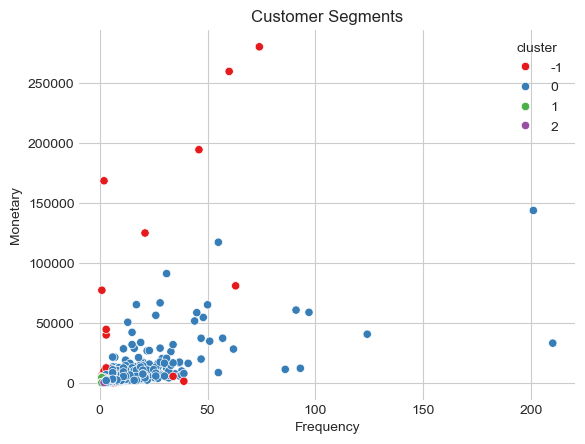

In [913]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='cluster',
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

In [914]:
from sklearn.metrics import silhouette_score

labels = rfm['cluster']
mask = labels != -1

X_clean = rfm_scaled[mask]
y_clean = labels[mask]

score = silhouette_score(X_clean, y_clean)
print("Silhouette Score:", score)

Silhouette Score: 0.2386788559167584


In [915]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

eps_values = np.arange(0.2, 1.5, 0.05)
min_samples_values = range(3, 20)

best_score = -1
best_params = None

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(rfm_scaled)

        mask = labels != -1

        # skip bad cases
        if len(set(labels[mask])) < 2:
            continue

        X_clean = rfm_scaled[mask]
        y_clean = labels[mask]

        score = silhouette_score(X_clean, y_clean)

        results.append([eps, min_samples, score, len(set(y_clean)), sum(labels == -1)])

        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)

print("BEST EPS:", best_params[0])
print("BEST MIN_SAMPLES:", best_params[1])
print("BEST SILHOUETTE SCORE:", best_score)

BEST EPS: 0.5499999999999999
BEST MIN_SAMPLES: 19
BEST SILHOUETTE SCORE: 0.3782298447370292


In [917]:
final_dbscan = DBSCAN(
    eps=0.55,
    min_samples=19
)

rfm['cluster'] = final_dbscan.fit_predict(rfm_scaled)

In [918]:
rfm['cluster'].value_counts()

cluster
 0    2813
 1    1475
-1      51
Name: count, dtype: int64

In [919]:
cluster_analysis_new = rfm.groupby('cluster')[['Recency','Frequency','Monetary']].mean()
cluster_analysis_new

,Recency,Frequency,Monetary
cluster,,,
-1,101.098039,13.000000,31882.013333
0,58.484181,5.829364,2396.181398
1,157.128814,1.000000,353.063011


In [920]:
rfm_DBSCAN = rfm[['Recency', 'Frequency', 'Monetary', 'cluster']]
cluster_map = {
    -1: "Outlier",
    0: "Regular Customers",
    1: "Lost Customers",
}

rfm_DBSCAN['Segment'] = rfm_DBSCAN['cluster'].map(cluster_map)
rfm_DBSCAN.head()

,Recency,Frequency,Monetary,cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,-1,Outlier
12347,2,7,4310.00,0,Regular Customers
12348,75,4,1797.24,0,Regular Customers
12349,19,1,1757.55,1,Lost Customers
12350,310,1,334.40,1,Lost Customers


### K Means

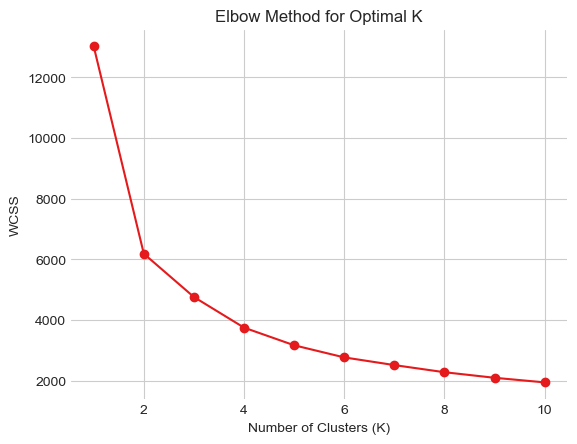

In [922]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [923]:
k_values = range(2, 11)

silhouette_scores = []

for k in k_values:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"K = {k}, Silhouette Score = {score}")

K = 2, Silhouette Score = 0.4325914911512414
K = 3, Silhouette Score = 0.3275814721600058
K = 4, Silhouette Score = 0.33448611643250764
K = 5, Silhouette Score = 0.3249292540439885
K = 6, Silhouette Score = 0.32010310664664543
K = 7, Silhouette Score = 0.3007015945145836
K = 8, Silhouette Score = 0.2950171232017039
K = 9, Silhouette Score = 0.2960974018102918
K = 10, Silhouette Score = 0.29541406231660206


### k = 2

In [938]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
rfm['kmeans_cluster'] = kmeans.fit_predict(rfm_scaled)

In [940]:
rfm.head()

,Recency,Frequency,Monetary,cluster,Segment,kmeans_cluster
CustomerID,,,,,,
12346,326,1,77183.60,-1,Outlier,0
12347,2,7,4310.00,0,Regular Customers,0
12348,75,4,1797.24,0,Regular Customers,0
12349,19,1,1757.55,1,Lost Customers,1
12350,310,1,334.40,1,Lost Customers,1


In [942]:
comparison = pd.DataFrame({
    'Model': ['DBSCAN', 'K-Means'],
    'k/Clusters': ['Auto (eps=0.55)', 'k=2'],  # Add clusters info
    'Silhouette Score': [0.378, 0.433]
})

comparison

,Model,k/Clusters,Silhouette Score
0,DBSCAN,Auto (eps=0.55),0.378
1,K-Means,k=2,0.433


In [944]:
rfm_KMeans = rfm[['Recency', 'Frequency', 'Monetary', 'kmeans_cluster']]
rfm_KMeans.head()

,Recency,Frequency,Monetary,kmeans_cluster
CustomerID,,,,
12346,326,1,77183.60,0
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,1
12350,310,1,334.40,1


In [946]:
cluster_map = {
    0: "Regular Customers",
    1: "Lost Customers",
}

rfm_KMeans['Segment_k'] = rfm_KMeans['kmeans_cluster'].map(cluster_map)

In [948]:
rfm_KMeans.head()

,Recency,Frequency,Monetary,kmeans_cluster,Segment_k
CustomerID,,,,,
12346,326,1,77183.60,0,Regular Customers
12347,2,7,4310.00,0,Regular Customers
12348,75,4,1797.24,0,Regular Customers
12349,19,1,1757.55,1,Lost Customers
12350,310,1,334.40,1,Lost Customers


## PCA Visualization

In [951]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

In [953]:
pca_df = pd.DataFrame(
    rfm_pca,
    columns=['PC1', 'PC2'],
    index=rfm.index
)

pca_df['Cluster'] = rfm['cluster']

In [955]:
pca_df.head()

,PC1,PC2,Cluster
CustomerID,,,
12346,0.346969,2.577517,-1
12347,2.499734,-0.584486,0
12348,0.698471,0.773031,0
12349,0.076355,-0.531849,1
12350,-1.871853,0.756331,1


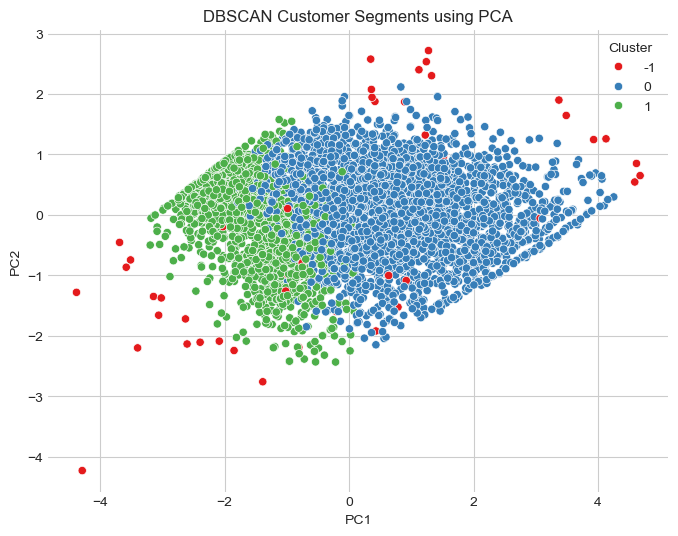

In [957]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("DBSCAN Customer Segments using PCA")
plt.show()

In [959]:
pca_df_k = pd.DataFrame(
    rfm_pca,
    columns=['PC1', 'PC2'],
    index=rfm.index
)

pca_df_k['Cluster'] = rfm['kmeans_cluster']

In [961]:
pca_df_k.head()

,PC1,PC2,Cluster
CustomerID,,,
12346,0.346969,2.577517,0
12347,2.499734,-0.584486,0
12348,0.698471,0.773031,0
12349,0.076355,-0.531849,1
12350,-1.871853,0.756331,1


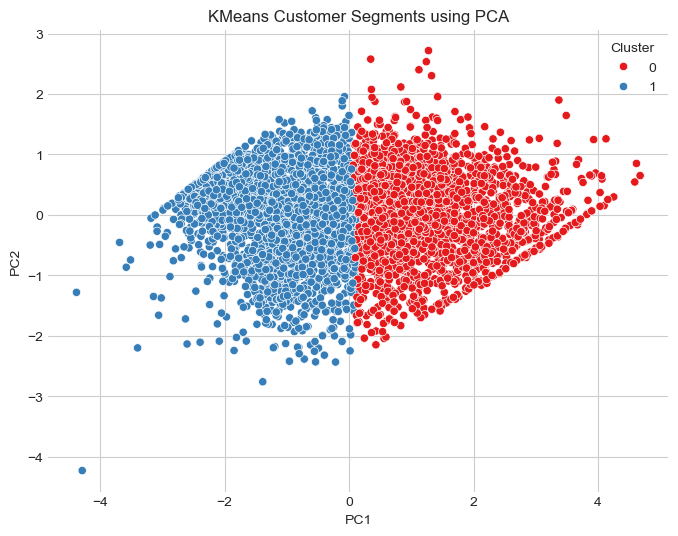

In [963]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df_k,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("KMeans Customer Segments using PCA")
plt.show()

## For an Business perspective we will go with the value K = 4 ( KMeans Algorithm )

In [986]:
rfm_4 = rfm.copy()

In [988]:
rfm_4 = rfm_4[['Recency','Frequency','Monetary']]

In [990]:
rfm_4.shape

(4339, 3)

In [992]:
kmeans_ = KMeans(n_clusters=4, random_state=42, n_init=20)
rfm_4['kmeans_cluster'] = kmeans_.fit_predict(rfm_scaled)

In [994]:
rfm_4.head()

,Recency,Frequency,Monetary,kmeans_cluster
CustomerID,,,,
12346,326,1,77183.60,0
12347,2,7,4310.00,2
12348,75,4,1797.24,0
12349,19,1,1757.55,3
12350,310,1,334.40,1


In [998]:
rfm_4['kmeans_cluster'].unique()

array([0, 2, 3, 1])

In [1004]:
pca_df_k_4 = pd.DataFrame(
    rfm_pca,
    columns=['PC1', 'PC2'],
    index=rfm.index
)


In [1006]:
pca_df_k_4.head()

,PC1,PC2
CustomerID,,
12346,0.346969,2.577517
12347,2.499734,-0.584486
12348,0.698471,0.773031
12349,0.076355,-0.531849
12350,-1.871853,0.756331


In [1008]:
pca_df_k_4['Cluster'] = rfm_4['kmeans_cluster']
pca_df_k_mm.head()

,PC1,PC2,Cluster
CustomerID,,,
12346,0.346969,2.577517,0
12347,2.499734,-0.584486,2
12348,0.698471,0.773031,0
12349,0.076355,-0.531849,3
12350,-1.871853,0.756331,1


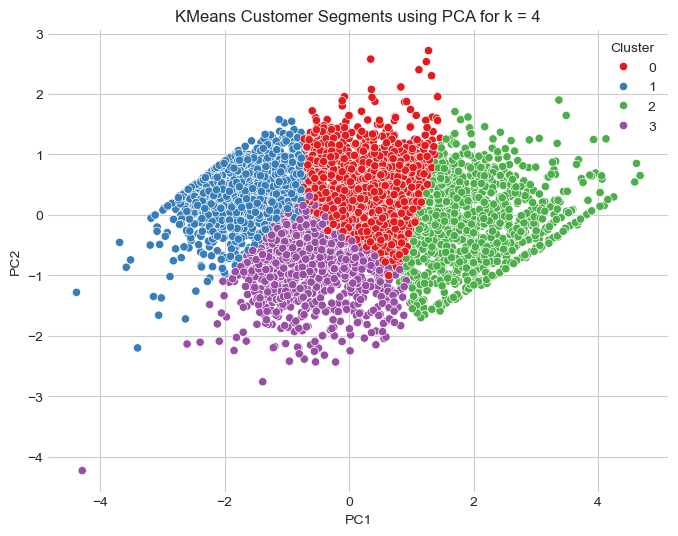

In [1012]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df_k_4,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("KMeans Customer Segments using PCA for k = 4")
plt.show()

In [1179]:
rfm_4.groupby('kmeans_cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
kmeans_cluster,,,
0,83.848071,3.536174,1412.666988
1,231.673527,1.196445,314.489018
2,13.754221,10.782364,6027.611276
3,36.259375,1.420833,383.571647


## FINAL INTERPRETATION FROM CLUSTERING

In [734]:
rfm_DBSCAN.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
Lost Customers,157.128814,1.000000,353.063011
Outlier,101.098039,13.000000,31882.013333
Regular Customers,58.484181,5.829364,2396.181398


In [736]:
rfm_KMeans.groupby('Segment_k')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment_k,,,
Lost Customers,144.321780,1.469833,429.044357
Regular Customers,32.046454,7.542957,3938.327788


In [748]:
rfm_KMeans['kmeans_cluster'].value_counts().sort_index()

kmeans_cluster
0    2002
1    2337
Name: count, dtype: int64

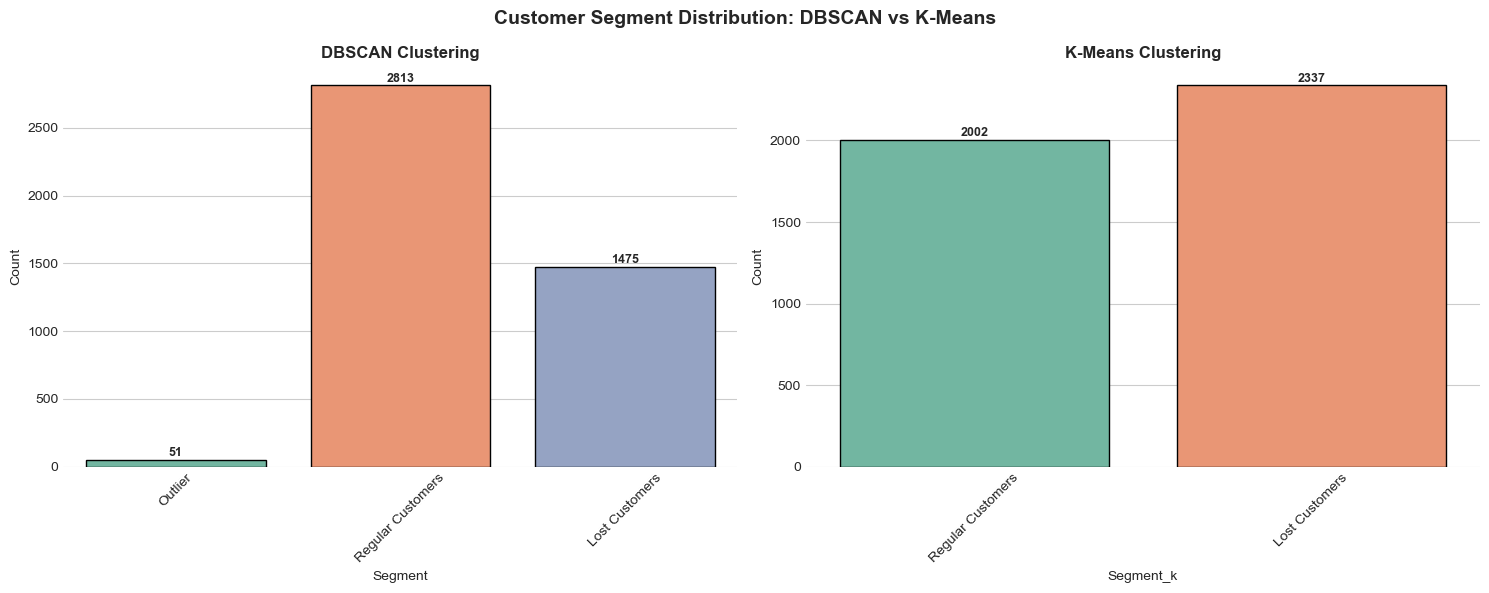

In [742]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: DBSCAN Segments
ax1 = sns.countplot(data=rfm_DBSCAN, x='Segment', palette='Set2', edgecolor='black', ax=ax1)
ax1.set_title('DBSCAN Clustering', fontsize=12, fontweight='bold')
ax1.set_xlabel('Segment', fontsize=10)
ax1.set_ylabel('Count', fontsize=10)
ax1.tick_params(axis='x', rotation=45)

# Add numbers on top of bars for DBSCAN
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: K-Means Segments
ax2 = sns.countplot(data=rfm_KMeans, x='Segment_k', palette='Set2', edgecolor='black', ax=ax2)
ax2.set_title('K-Means Clustering', fontsize=12, fontweight='bold')
ax2.set_xlabel('Segment_k', fontsize=10)
ax2.set_ylabel('Count', fontsize=10)
ax2.tick_params(axis='x', rotation=45)

# Add numbers on top of bars for K-Means
for bar in ax2.patches:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Customer Segment Distribution: DBSCAN vs K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

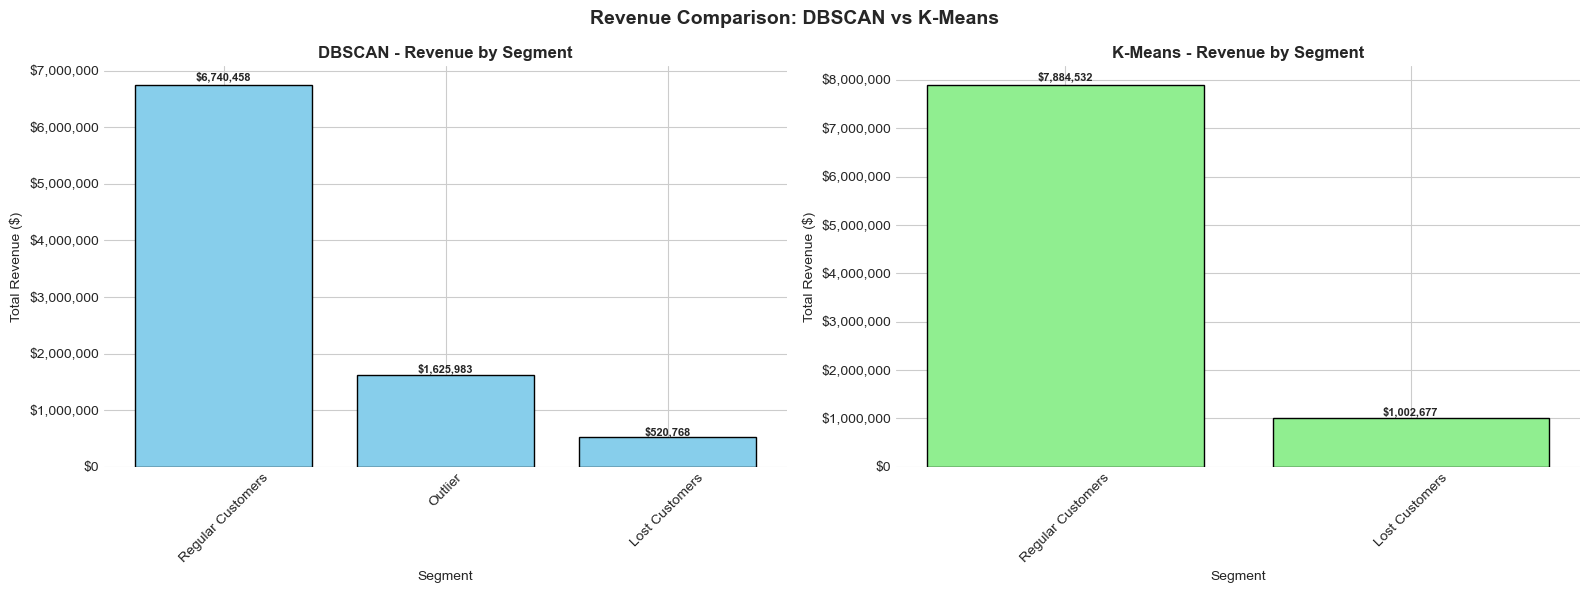

In [752]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Set style
sns.set_style("whitegrid")

# Create figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: DBSCAN Revenue
revenue_dbscan = rfm_DBSCAN.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
bars1 = ax1.bar(revenue_dbscan.index, revenue_dbscan.values, color='skyblue', edgecolor='black')
ax1.set_title('DBSCAN - Revenue by Segment', fontsize=12, fontweight='bold')
ax1.set_xlabel('Segment', fontsize=10)
ax1.set_ylabel('Total Revenue ($)', fontsize=10)
ax1.tick_params(axis='x', rotation=45)

# Add value labels for DBSCAN
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 2: K-Means Revenue
revenue_kmeans = rfm_KMeans.groupby('Segment_k')['Monetary'].sum().sort_values(ascending=False)
bars2 = ax2.bar(revenue_kmeans.index, revenue_kmeans.values, color='lightgreen', edgecolor='black')
ax2.set_title('K-Means - Revenue by Segment', fontsize=12, fontweight='bold')
ax2.set_xlabel('Segment', fontsize=10)
ax2.set_ylabel('Total Revenue ($)', fontsize=10)
ax2.tick_params(axis='x', rotation=45)

# Add value labels for K-Means
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.suptitle('Revenue Comparison: DBSCAN vs K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Insights from Customer Segmentation

- The majority of customers fall under the Regular segment for DBSCAN and comparable for KMeans, which forms the main revenue-driving base of the business.
- Outliers customers are very few in number but contribute a high amount of revenue per customer, making them the most valuable group.
- A significant portion of customers are classified as Lost Customers, which indicates a high churn rate and need for re-engagement strategies.
- Low Engagement customers show weak purchasing behavior and low interaction with the business.

Overall, the business is highly dependent on Regular Customers, while VIP customers bring high value. However, the large number of lost customers highlights the need for strong retention and win-back campaigns to improve long-term revenue.

## Recomendation System

In [1019]:
df_rev.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,Month_Num
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,12


In [1023]:
df_merged = df_rev.merge(
    rfm_4[['kmeans_cluster']],
    left_on='CustomerID',
    right_index=True,
    how='inner'
)

In [1035]:
df_merged['kmeans_cluster'].value_counts()

kmeans_cluster
2    249650
0     92373
3     28992
1     21717
Name: count, dtype: int64

In [1062]:
df_merged.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,Month_Num,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,12,0


In [1060]:
df_merged.rename(columns={'kmeans_cluster': 'Cluster'}, inplace=True)

In [1066]:
cluster_product = df_merged.groupby(
    ['Cluster', 'Description']
)['Quantity'].sum().reset_index()

cluster_product

,Cluster,Description,Quantity
0,0,4 PURPLE FLOCK DINNER CANDLES,15
1,0,50'S CHRISTMAS GIFT BAG LARGE,338
2,0,DOLLY GIRL BEAKER,178
3,0,I LOVE LONDON MINI BACKPACK,54
4,0,NINE DRAWER OFFICE TIDY,17
...,...,...,...
12843,3,ZINC T-LIGHT HOLDER STAR LARGE,178
12844,3,ZINC T-LIGHT HOLDER STARS SMALL,188
12845,3,ZINC WILLIE WINKIE CANDLE STICK,241
12846,3,ZINC WIRE KITCHEN ORGANISER,5


In [1068]:
cluster_product_sorted = cluster_product.sort_values(
    ['Cluster', 'Quantity'],
    ascending=[True, False]
)

cluster_product_sorted

,Cluster,Description,Quantity
1744,0,MEDIUM CERAMIC TOP STORAGE JAR,74884
2852,0,SMALL CHINESE STYLE SCISSOR,11655
1991,0,PACK OF 72 RETROSPOT CAKE CASES,10016
3265,0,WHITE HANGING HEART T-LIGHT HOLDER,9659
3341,0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,9308
...,...,...,...
12743,3,WHITE/PINK CHICK DECORATION,1
12744,3,WHITE/PINK CHICK EASTER DECORATION,1
12751,3,WISE MAN STAR SHAPE EGG PAN,1
12753,3,WOOD AND GLASS MEDICINE CABINET,1


In [1070]:
top_products = cluster_product_sorted.groupby('Cluster').head(10)
top_products 

,Cluster,Description,Quantity
1744,0,MEDIUM CERAMIC TOP STORAGE JAR,74884
2852,0,SMALL CHINESE STYLE SCISSOR,11655
1991,0,PACK OF 72 RETROSPOT CAKE CASES,10016
3265,0,WHITE HANGING HEART T-LIGHT HOLDER,9659
3341,0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,9308
194,0,ASSORTED COLOURS SILK FAN,8040
1555,0,JUMBO BAG RED RETROSPOT,7643
1019,0,FAIRY CAKE FLANNEL ASSORTED COLOUR,7583
187,0,ASSORTED COLOUR BIRD ORNAMENT,6930
101,0,60 TEATIME FAIRY CAKE CASES,6050


In [1072]:
def recommend_by_cluster(cluster_id, top_n=5):

    products = cluster_product_sorted[
        cluster_product_sorted['Cluster'] == cluster_id
    ]

    return products['Description'].head(top_n).tolist()

In [1076]:
recommend_by_cluster(1)

['WORLD WAR 2 GLIDERS ASSTD DESIGNS',
 'GIRLS ALPHABET IRON ON PATCHES ',
 'ASSORTED LAQUERED INCENSE HOLDERS',
 'RED  HARMONICA IN BOX ',
 'SMALL CERAMIC TOP STORAGE JAR ']

In [1078]:
product_matrix = df_merged.pivot_table(
    index='Description',
    columns='CustomerID',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)
product_matrix

CustomerID,12346,12347,12348,12349,12350,12352,12353,12354,12355,12356,...,18273,18274,18276,18277,18278,18280,18281,18282,18283,18287
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50'S CHRISTMAS GIFT BAG LARGE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DOLLY GIRL BEAKER,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I LOVE LONDON MINI BACKPACK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I LOVE LONDON MINI RUCKSACK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZINC T-LIGHT HOLDER STARS SMALL,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZINC TOP 2 DOOR WOODEN SHELF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZINC WILLIE WINKIE CANDLE STICK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [1099]:
product_matrix_binary = product_matrix.applymap(lambda x: 1 if x > 0 else 0)

## Cosine Similarity

In [1104]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(product_matrix_binary)

In [1106]:
product_similarity_df = pd.DataFrame(
    similarity,
    index=product_matrix_binary.index,
    columns=product_matrix_binary.index
)
product_similarity_df

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.017961,0.023583,0.000000,0.000000,0.028050,0.000000,0.031384,0.017125,...,0.000000,0.042333,0.043885,0.032001,0.000000,0.026774,0.000000,0.061379,0.000000,0.042333
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.058277,0.038261,0.000000,0.036073,0.060676,0.332508,0.033945,0.083348,...,0.000000,0.045787,0.047465,0.034612,0.000000,0.094114,0.000000,0.033193,0.000000,0.022893
DOLLY GIRL BEAKER,0.017961,0.058277,1.000000,0.144437,0.100000,0.037139,0.046852,0.066259,0.061159,0.200227,...,0.000000,0.023570,0.048868,0.089087,0.000000,0.096896,0.000000,0.034174,0.028868,0.070711
I LOVE LONDON MINI BACKPACK,0.023583,0.038261,0.144437,1.000000,0.131306,0.048766,0.041013,0.043501,0.126195,0.112676,...,0.000000,0.061898,0.048125,0.035093,0.000000,0.039148,0.000000,0.056091,0.000000,0.061898
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.100000,0.131306,1.000000,0.000000,0.000000,0.000000,0.000000,0.095346,...,0.000000,0.000000,0.000000,0.089087,0.000000,0.074536,0.000000,0.085436,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZINC T-LIGHT HOLDER STARS SMALL,0.026774,0.094114,0.096896,0.039148,0.074536,0.041523,0.081484,0.049386,0.052098,0.049747,...,0.074536,0.070273,0.136590,0.551133,0.105409,1.000000,0.049690,0.133728,0.043033,0.070273
ZINC TOP 2 DOOR WOODEN SHELF,0.000000,0.000000,0.000000,0.000000,0.000000,0.061898,0.052058,0.000000,0.029123,0.000000,...,0.000000,0.000000,0.040723,0.059391,0.000000,0.049690,1.000000,0.056957,0.000000,0.000000
ZINC WILLIE WINKIE CANDLE STICK,0.061379,0.033193,0.034174,0.056091,0.085436,0.031730,0.053371,0.047174,0.014929,0.040730,...,0.000000,0.040275,0.083501,0.098946,0.000000,0.133728,0.056957,1.000000,0.024663,0.040275


In [1115]:
def recommend_similar_products(product_name, top_n=5):

    if product_name not in product_similarity_df.index:
        return "Product not found"

    similar_scores = product_similarity_df[product_name].sort_values(ascending=False)

    return similar_scores.iloc[1:top_n+1].index.tolist()

In [1117]:
recommend_similar_products("WHITE HANGING HEART T-LIGHT HOLDER")

['RED HANGING HEART T-LIGHT HOLDER',
 'CANDLEHOLDER PINK HANGING HEART',
 'HEART OF WICKER LARGE',
 'HEART OF WICKER SMALL',
 'WOODEN PICTURE FRAME WHITE FINISH']

## HYBRID RECOMMENDATION SYSTEM

In [1156]:
customer_id = 17850

customer_cluster = df_merged.loc[customer_id, 'Cluster']

print(customer_cluster)

0


In [1158]:
cluster_products = cluster_product_sorted[
    cluster_product_sorted['Cluster'] == customer_cluster
]

top_cluster_products = cluster_products['Description'].head(10).tolist()

print(top_cluster_products)

['MEDIUM CERAMIC TOP STORAGE JAR', 'SMALL CHINESE STYLE SCISSOR', 'PACK OF 72 RETROSPOT CAKE CASES', 'WHITE HANGING HEART T-LIGHT HOLDER', 'WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'ASSORTED COLOURS SILK FAN', 'JUMBO BAG RED RETROSPOT', 'FAIRY CAKE FLANNEL ASSORTED COLOUR', 'ASSORTED COLOUR BIRD ORNAMENT', '60 TEATIME FAIRY CAKE CASES']


In [1160]:
customer_history = df_merged[
    df_merged['CustomerID'] == customer_id
]['Description'].unique()

print(customer_history)

['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' 'KNITTED UNION FLAG HOT WATER BOTTLE'
 'RED WOOLLY HOTTIE WHITE HEART.' 'SET 7 BABUSHKA NESTING BOXES'
 'GLASS STAR FROSTED T-LIGHT HOLDER' 'HAND WARMER UNION JACK'
 'HAND WARMER RED POLKA DOT' 'EDWARDIAN PARASOL RED'
 'RETRO COFFEE MUGS ASSORTED' 'SAVE THE PLANET MUG'
 'VINTAGE BILLBOARD DRINK ME MUG' 'VINTAGE BILLBOARD LOVE/HATE MUG'
 'WOOD 2 DRAWER CABINET WHITE FINISH' 'WOOD S/3 CABINET ANT WHITE FINISH'
 'WOODEN PICTURE FRAME WHITE FINISH' 'WOODEN FRAME ANTIQUE WHITE '
 'EDWARDIAN PARASOL BLACK' 'IVORY EMBROIDERED QUILT '
 'JUMBO SHOPPER VINTAGE RED PAISLEY']


In [1162]:
similar_products = []

for product in customer_history:

    try:
        recs = recommend_similar_products(product, top_n=3)

        similar_products.extend(recs)

    except:
        pass

In [1164]:
similar_products = list(set(similar_products))

In [1166]:
similar_products 

['WICKER STAR ',
 'EDWARDIAN PARASOL PINK',
 'RED HANGING HEART T-LIGHT HOLDER',
 'POTTING SHED TEA MUG',
 'EDWARDIAN PARASOL BLACK',
 'WHITE SKULL HOT WATER BOTTLE ',
 'VINTAGE BILLBOARD LOVE/HATE MUG',
 'CANDLEHOLDER PINK HANGING HEART',
 'SMALL RED BABUSHKA NOTEBOOK ',
 'HOME SWEET HOME MUG',
 'RED WOOLLY HOTTIE WHITE HEART.',
 'KINGS CHOICE MUG',
 'JUMBO BAG SCANDINAVIAN BLUE PAISLEY',
 'HAND WARMER OWL DESIGN',
 'HEART OF WICKER LARGE',
 'WOODEN PICTURE FRAME WHITE FINISH',
 'SAVE THE PLANET MUG',
 'LANTERN CREAM GAZEBO ',
 'WHITE HANGING HEART T-LIGHT HOLDER',
 'TRIPLE HOOK ANTIQUE IVORY ROSE',
 'JUMBO  BAG BAROQUE BLACK WHITE',
 'METAL 4 HOOK HANGER FRENCH CHATEAU',
 'MOROCCAN TEA GLASS',
 'COLOUR GLASS. STAR T-LIGHT HOLDER',
 'KNITTED UNION FLAG HOT WATER BOTTLE',
 'HOT WATER BOTTLE KEEP CALM',
 'EDWARDIAN PARASOL RED',
 'WOOD 2 DRAWER CABINET WHITE FINISH',
 'ENCHANTED BIRD COATHANGER 5 HOOK',
 'VINTAGE BILLBOARD MUG ',
 'WOODEN FRAME ANTIQUE WHITE ',
 'HANGING METAL STAR LANT

In [1168]:
similar_products = [
    p for p in similar_products
    if p not in customer_history
]
similar_products

['WICKER STAR ',
 'EDWARDIAN PARASOL PINK',
 'RED HANGING HEART T-LIGHT HOLDER',
 'POTTING SHED TEA MUG',
 'WHITE SKULL HOT WATER BOTTLE ',
 'CANDLEHOLDER PINK HANGING HEART',
 'SMALL RED BABUSHKA NOTEBOOK ',
 'HOME SWEET HOME MUG',
 'KINGS CHOICE MUG',
 'JUMBO BAG SCANDINAVIAN BLUE PAISLEY',
 'HAND WARMER OWL DESIGN',
 'HEART OF WICKER LARGE',
 'LANTERN CREAM GAZEBO ',
 'TRIPLE HOOK ANTIQUE IVORY ROSE',
 'JUMBO  BAG BAROQUE BLACK WHITE',
 'METAL 4 HOOK HANGER FRENCH CHATEAU',
 'MOROCCAN TEA GLASS',
 'COLOUR GLASS. STAR T-LIGHT HOLDER',
 'HOT WATER BOTTLE KEEP CALM',
 'ENCHANTED BIRD COATHANGER 5 HOOK',
 'VINTAGE BILLBOARD MUG ',
 'HANGING METAL STAR LANTERN',
 'RETROSPOT HEART HOT WATER BOTTLE',
 'HAND WARMER SCOTTY DOG DESIGN',
 'DOORKNOB CERAMIC IVORY',
 'HAND WARMER RED LOVE HEART',
 'SMALL PURPLE BABUSHKA NOTEBOOK ',
 'MONTANA DIAMOND CLUSTER EARRINGS',
 'EDWARDIAN PARASOL NATURAL',
 'VINTAGE BILLBOARD TEA MUG',
 'LARGE PURPLE BABUSHKA NOTEBOOK  ',
 'DIAMANTE HAIR GRIP PACK/2 CRYS

In [1170]:
final_recommendations = list(
    set(top_cluster_products + similar_products)
)
final_recommendations[:10]

['WICKER STAR ',
 'EDWARDIAN PARASOL PINK',
 'RED HANGING HEART T-LIGHT HOLDER',
 'POTTING SHED TEA MUG',
 'WHITE SKULL HOT WATER BOTTLE ',
 'CANDLEHOLDER PINK HANGING HEART',
 'SMALL RED BABUSHKA NOTEBOOK ',
 'HOME SWEET HOME MUG',
 'KINGS CHOICE MUG',
 'JUMBO BAG SCANDINAVIAN BLUE PAISLEY']

In [1175]:
def hybrid_recommend(customer_id):

    cluster = rfm.loc[customer_id, 'kmeans_cluster']

    history = df_merged[
        df_merged['CustomerID'] == customer_id
    ]['Description'].unique()

    cluster_products = cluster_product_sorted[
        cluster_product_sorted['Cluster'] == cluster
    ]['Description'].head(10).tolist()

    similar_products = []

    for product in history:
        if product in product_similarity_df.index:
            recs = recommend_similar_products(product, top_n=3)
            similar_products.extend(recs)

    similar_products = list(set(similar_products))

    final_similar = [
        p for p in similar_products
        if p not in history
    ]

    final_recommendations = list(set(cluster_products + final_similar))

    return final_recommendations[:10]

In [1177]:
hybrid_recommend(17850)

['WICKER STAR ',
 'EDWARDIAN PARASOL PINK',
 'RED HANGING HEART T-LIGHT HOLDER',
 'POTTING SHED TEA MUG',
 'WHITE SKULL HOT WATER BOTTLE ',
 'CANDLEHOLDER PINK HANGING HEART',
 'SMALL RED BABUSHKA NOTEBOOK ',
 'HOME SWEET HOME MUG',
 'KINGS CHOICE MUG',
 'JUMBO BAG SCANDINAVIAN BLUE PAISLEY']